# HW4: Reinforcement Learning
# Part 1: Planar Drone
Ting-Wei Hsu (twhsu3)

In [41]:
import numpy as np
from qpsolvers import solve_problem, Problem
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Suppress the display of very small numbers
np.set_printoptions(suppress=True)


## Dynamical System

Consider a planar drone with the equations of motion
$$
\begin{aligned}
\dot{p}_x &= v_x \\
\dot{p}_z &= v_z \\
\dot{\theta} &= \omega \\
m\dot{v}_x &= -(T_1 + T_2)\sin\theta \\
m\dot{v}_z &= (T_1 + T_2)\cos\theta - mg \\
J_y \dot{\omega} &= r(T_1 - T_2)
\end{aligned}
$$

where $m = 0.45$ is the mass; 
$r = 0.14$ is the spar length;
$J_y = 0.09$ is the moment of inertia about the $y$ (out-of-plane) axis;
$g = 9.81$ is the acceleration of gravity;
$p_x$ and $p_z$ are the components of position;
$\theta$ is the orientation;
$v_x$ and $v_z$ are the components of linear velocity;
$\omega$ is the angular velocity;
$T_1$ and $T_2$ are the forces produced by each rotor.

We define the state and input as
$$
x = [p_x,\; p_z,\; \theta,\; v_x,\; v_z,\; \omega]^\top,
 \qquad
u = [T_1,\; T_2]^\top
$$
and the dynamicas as 
$$
\dot{x} = f(x,u)
$$

In [42]:
m = 0.45
r = 0.14
Jy = 0.09
grav = 9.81
dt = 0.04
N = 25
sim_time = 5.0

x_dim = 6
u_dim = 2

def dynamics(x, u):
    px, pz, theta, vx, vz, omega = x
    T1, T2 = u
    return np.array([
        vx,
        vz,
        omega,
        -(T1 + T2) / m * np.sin(theta),
        (T1 + T2) / m * np.cos(theta) - grav,
        r * (T1 - T2) / Jy,
    ])


def Jacobian_dynamics(x, u):
    _, _, theta, _, _, _ = x
    T1, T2 = u

    A = np.zeros((x_dim, x_dim))
    A[0, 3] = 1.0
    A[1, 4] = 1.0
    A[2, 5] = 1.0
    A[3, 2] = -(T1 + T2) / m * np.cos(theta)
    A[4, 2] = -(T1 + T2) / m * np.sin(theta)

    B = np.zeros((x_dim, u_dim))
    B[3, :] = -(1.0 / m) * np.sin(theta)
    B[4, :] =  (1.0 / m) * np.cos(theta)
    B[5, 0] =  r / Jy
    B[5, 1] = -r / Jy
    return A, B


In [43]:
x_start = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
x_goal  = np.array([3.0, 0.0, 0.0, 0.0, 0.0, 0.0])
u_ref = np.array([m * grav / 2.0, m * grav / 2.0])

## Gymnasium Environment

This environment keeps the planar quadrotor state from above. The observation augments that state with the relative goal and obstacle positions. The policy action is normalized in `[-1, 1]^2` and mapped inside the environment to physical rotor thrusts constrained to `[0, 10]` N. The state limits are stored as `(x_dim, 2)` arrays whose rows are `[min, max]` pairs for each state variable.

In [44]:

import gymnasium as gym
from gymnasium import spaces


DEFAULT_STATE_LIMIT = np.array([
    [-1.0, 4.0],
    [-1.5, 1.5],
    [-np.pi, np.pi],
    [-6.0, 6.0],
    [-6.0, 6.0],
    [-12.0, 12.0],
], dtype=np.float64)

DEFAULT_OBSTACLE_LIMIT = np.array([
    [0.8, 2.5],
    [-0.8, 0.8],
], dtype=np.float64)


class PlanarQuad(gym.Env):
    """Planar quadrotor reaching task with one circular obstacle.

    The policy action is normalized to [-1, 1]^2. Inside the environment it is
    converted to physical rotor thrusts constrained to [0, 10] N. A normalized
    action of 0 maps to hover thrust so PPO starts from a sensible command.
    """

    metadata = {'render_modes': ['rgb_array'], 'render_fps': 10}

    def __init__(
        self,
        goal=x_goal,
        start=x_start,
        dt=dt,
        max_num_steps=400,
        state_limit=DEFAULT_STATE_LIMIT,
        obstacle_limit=DEFAULT_OBSTACLE_LIMIT,
        dynamics_fn=dynamics,
        random_start=False,
        random_obstacle=True,
        obstacle=None,
        start_noise=np.array([0.03, 0.03, 0.03, 0.05, 0.05, 0.08]),
    ):
        super().__init__()

        self.dt = float(dt)
        self.max_num_steps = int(max_num_steps)
        self.goal = np.array(goal, dtype=np.float64, copy=True)
        self.start = np.array(start, dtype=np.float64, copy=True)
        self.random_start = bool(random_start)
        self.random_obstacle = bool(random_obstacle)
        self.start_noise = np.array(start_noise, dtype=np.float64, copy=True)
        self.dynamics_fn = dynamics_fn

        self.state_limit = np.array(state_limit, dtype=np.float64, copy=True)
        self.obstacle_limit = np.array(obstacle_limit, dtype=np.float64, copy=True)
        self.fixed_obstacle = (
            np.mean(self.obstacle_limit, axis=1)
            if obstacle is None
            else np.array(obstacle, dtype=np.float64, copy=True)
        )

        self.goal_position_tolerance = 0.15
        self.goal_velocity_tolerance = 0.2
        self.goal_angle_tolerance = 0.2
        self.goal_omega_tolerance = 0.25

        self.drone_radius = r
        self.obstacle_radius = r
        self.safety_clearance = 0.35

        self.hover_thrust = np.array(u_ref, dtype=np.float64, copy=True)
        self.min_thrust = 0.0
        self.max_thrust = 10.0

        obs_low = np.concatenate([
            self.state_limit[:, 0],
            self.goal[:2] - self.state_limit[:2, 1],
            self.obstacle_limit[:, 0] - self.state_limit[:2, 1],
        ]).astype(np.float32)
        obs_high = np.concatenate([
            self.state_limit[:, 1],
            self.goal[:2] - self.state_limit[:2, 0],
            self.obstacle_limit[:, 1] - self.state_limit[:2, 0],
        ]).astype(np.float32)
        self.observation_space = spaces.Box(low=obs_low, high=obs_high, dtype=np.float32)
        self.action_space = spaces.Box(
            low=-np.ones(u_dim, dtype=np.float32),
            high=np.ones(u_dim, dtype=np.float32),
            dtype=np.float32,
        )

        self.state = None
        self.obstacle_center = None
        self.step_count = 0
        self.prev_goal_distance = None

    def _wrap_theta(self, theta):
        return ((theta + np.pi) % (2 * np.pi)) - np.pi

    def _get_observation(self):
        goal_rel = self.goal[:2] - self.state[:2]
        obstacle_rel = self.obstacle_center - self.state[:2]
        return np.concatenate([self.state, goal_rel, obstacle_rel]).astype(np.float32)

    def _goal_distance(self):
        return float(np.linalg.norm(self.goal[:2] - self.state[:2]))

    def _obstacle_distance(self):
        return float(np.linalg.norm(self.state[:2] - self.obstacle_center))

    def _state_in_bounds(self, state):
        return bool(np.all(state >= self.state_limit[:, 0]) and np.all(state <= self.state_limit[:, 1]))

    def _in_bounds(self):
        return self._state_in_bounds(self.state)

    def _collision_radius(self):
        return self.drone_radius + self.obstacle_radius

    def _is_success(self):
        return bool(
            self._goal_distance() <= self.goal_position_tolerance
            and np.linalg.norm(self.state[3:5]) <= self.goal_velocity_tolerance
            and abs(self.state[2]) <= self.goal_angle_tolerance
            and abs(self.state[5]) <= self.goal_omega_tolerance
        )

    def _is_collision(self):
        clearance = self._obstacle_distance() - self._collision_radius()
        return self._obstacle_distance() <= self._collision_radius(), clearance

    def _physical_action(self, action):
        normalized_action = np.asarray(action, dtype=np.float64).reshape(-1)
        if normalized_action.size != u_dim:
            raise ValueError(f"Expected action with {u_dim} elements, got {normalized_action.size}")
        normalized_action = np.clip(normalized_action, -1.0, 1.0)
        thrust = np.empty_like(normalized_action)
        for i, a in enumerate(normalized_action):
            if a >= 0.0:
                thrust[i] = self.hover_thrust[i] + a * (self.max_thrust - self.hover_thrust[i])
            else:
                thrust[i] = self.hover_thrust[i] + a * (self.hover_thrust[i] - self.min_thrust)
        thrust = np.clip(thrust, self.min_thrust, self.max_thrust)
        
        return thrust, normalized_action

    def _sample_initial_state(self, random_start=None):
        random_start = self.random_start if random_start is None else bool(random_start)
        if random_start:
            state = self.start.copy()
            state[:2] = self.np_random.uniform(
                self.state_limit[:2, 0] * 0.6,
                self.state_limit[:2, 1] * 0.6,
            )
            state[2] = self.np_random.uniform(-0.4, 0.4)
            state[3:5] = self.np_random.uniform(-0.5, 0.5, size=2)
            state[5] = self.np_random.uniform(-1.0, 1.0)
        else:
            state = self.start + self.np_random.normal(scale=self.start_noise)
        state[2] = self._wrap_theta(state[2])
        return state.astype(np.float64)

    def _sample_obstacle(self):
        return self.np_random.uniform(
            self.obstacle_limit[:, 0],
            self.obstacle_limit[:, 1],
        ).astype(np.float64)

    def _sample_feasible_reset(self, options):
        options = {} if options is None else dict(options)
        min_clearance = self._collision_radius() + 0.25
        random_start = options.get('random_start', self.random_start)
        x0 = options.get('x0')
        obstacle = options.get('obstacle')
        random_obstacle = options.get('random_obstacle', self.random_obstacle)

        for _ in range(1000):
            state = np.array(x0, dtype=np.float64, copy=True) if x0 is not None else self._sample_initial_state(random_start)
            if obstacle is not None:
                candidate_obstacle = np.array(obstacle, dtype=np.float64, copy=True)
            elif random_obstacle:
                candidate_obstacle = self._sample_obstacle()
            else:
                candidate_obstacle = self.fixed_obstacle.copy()
            state[2] = self._wrap_theta(state[2])
            start_clear = np.linalg.norm(state[:2] - candidate_obstacle) > min_clearance
            goal_clear = np.linalg.norm(self.goal[:2] - candidate_obstacle) > min_clearance
            if self._state_in_bounds(state) and start_clear and goal_clear:
                return state, candidate_obstacle
            if x0 is not None or obstacle is not None:
                break
        raise RuntimeError("Could not sample a feasible initial state and obstacle")

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)

        self.step_count = 0
        self.state, self.obstacle_center = self._sample_feasible_reset(options)
        self.prev_goal_distance = self._goal_distance()

        return self._get_observation(), {}

    def step(self, action):
        thrust, normalized_action = self._physical_action(action)

        sol = solve_ivp(
            lambda t, y: self.dynamics_fn(y, thrust),
            t_span=[0.0, self.dt],
            y0=self.state,
            t_eval=[self.dt],
            rtol=1e-8,
            atol=1e-10,
        )
        if not sol.success:
            raise RuntimeError(sol.message)
        self.state = sol.y[:, -1].astype(np.float64)
        self.state[2] = self._wrap_theta(self.state[2])

        goal_distance = self._goal_distance()
        success = self._is_success()
        collision, clearance = self._is_collision()
        out_of_bounds = not self._in_bounds()

        progress = self.prev_goal_distance - goal_distance
        speed = float(np.linalg.norm(self.state[3:5]))
        angle = abs(float(self.state[2]))
        omega = abs(float(self.state[5]))
        effort = float(np.linalg.norm(normalized_action) ** 2)

        reward = 10.0 * progress
        reward -= 0.5 * goal_distance
        reward -= 0.01 * speed
        reward -= 0.03 * angle
        reward -= 0.01 * omega
        reward -= 0.01 * effort

        if goal_distance < 0.75:
            reward += 2.0 * (0.75 - goal_distance) / 0.75
            reward -= 0.5 * speed
            reward -= 0.1 * angle
            reward -= 0.05 * omega
            
            if goal_distance < 0.1:
                reward -= 0.1 * speed
                reward -= 0.05 * angle
                reward -= 0.05 * omega

        if collision:
            reward -= 250.0
        elif clearance < self.safety_clearance:
            reward -= 5.0 * ((self.safety_clearance - clearance) / self.safety_clearance) ** 2

        if success:
            reward += 1000.0
        elif out_of_bounds:
            reward -= 250.0

        self.prev_goal_distance = goal_distance
        self.step_count += 1

        terminated = bool(success or collision or out_of_bounds)
        truncated = bool(self.step_count >= self.max_num_steps and not terminated)
        if truncated:
            reward -= 100.0

        if success:
            termination_reason = 'success'
        elif collision:
            termination_reason = 'collision'
        elif out_of_bounds:
            termination_reason = 'out_of_bounds'
        elif truncated:
            termination_reason = 'timeout'
        else:
            termination_reason = None

        info = {
            'is_success': success,
            'collision': collision,
            'out_of_bounds': out_of_bounds,
            'termination_reason': termination_reason,
            'goal_distance': goal_distance,
            'clearance': clearance,
            'physical_action': thrust.astype(np.float32),
        }

        return self._get_observation(), float(reward), terminated, truncated, info


Test rollouts

In [45]:

def rollout_random_policy(env, episodes=10, seed=0):
    returns = []
    lengths = []
    final_infos = []

    for episode in range(episodes):
        obs, info = env.reset(seed=seed + episode)
        total_reward = 0.0
        final_info = {}

        for step in range(env.max_num_steps):
            action = env.action_space.sample()
            obs, reward, terminated, truncated, info = env.step(action)
            total_reward += reward
            final_info = info
            if terminated or truncated:
                break

        returns.append(total_reward)
        lengths.append(step + 1)
        final_infos.append(final_info)
        print(
            f"episode={episode + 1:02d} return={total_reward:8.2f} "
            f"len={step + 1:3d} reason={final_info.get('termination_reason')} "
            f"goal_dist={final_info.get('goal_distance', np.nan):.2f} "
            f"clearance={final_info.get('clearance', np.nan):.2f}"
        )

    return returns, lengths, final_infos

env = PlanarQuad()
obs, info = env.reset(seed=0)
print("observation shape:", obs.shape)
print("action space:", env.action_space)
print("observation space:", env.observation_space)
for test_action in [
    -np.ones(u_dim),
    np.zeros(u_dim),
    np.ones(u_dim),
]:
    print(f"normalized action {test_action} maps to thrust {env._physical_action(test_action)[0]}")

rollout_returns, rollout_lengths, rollout_infos = rollout_random_policy(env, episodes=10, seed=1)


observation shape: (10,)
action space: Box(-1.0, 1.0, (2,), float32)
observation space: Box([ -1.         -1.5        -3.1415927  -6.         -6.        -12.
  -1.         -1.5        -3.2        -2.3      ], [ 4.         1.5        3.1415927  6.         6.        12.
  4.         1.5        3.5        2.3      ], (10,), float32)
normalized action [-1. -1.] maps to thrust [0. 0.]
normalized action [0. 0.] maps to thrust [2.20725 2.20725]
normalized action [1. 1.] maps to thrust [10. 10.]
episode=01 return= -278.54 len= 12 reason=out_of_bounds goal_dist=3.81 clearance=2.92
episode=02 return= -271.74 len= 19 reason=out_of_bounds goal_dist=2.31 clearance=1.39
episode=03 return= -285.38 len= 22 reason=out_of_bounds goal_dist=3.13 clearance=2.25
episode=04 return= -295.76 len= 21 reason=out_of_bounds goal_dist=4.05 clearance=3.05
episode=05 return= -272.72 len= 26 reason=out_of_bounds goal_dist=1.63 clearance=1.31
episode=06 return= -288.07 len= 26 reason=out_of_bounds goal_dist=2.90 cleara

## Training using PPO with Stable-Baselines3

In [46]:
import math
import os
import json
from stable_baselines3 import PPO
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.env_checker import check_env
import torch

check_env(PlanarQuad(), warn=True)

# Use Monitor so evaluation logs have episode returns, lengths, and success info.
env = Monitor(PlanarQuad())
eval_env = Monitor(PlanarQuad())

# Stable-Baselines3 expects LR schedules through learning_rate, not policy_kwargs.
# Set num_steps above lr_decay_start_timestep to train into the decay region.
num_steps = 1_000_000
initial_learning_rate = 3e-4
min_learning_rate = 1e-5
lr_decay_start_timestep = 450_000
decay_time_const = 100_000

def delayed_exponential_lr_schedule(progress_remaining: float) -> float:
    current_timestep = (1.0 - progress_remaining) * num_steps
    if current_timestep <= lr_decay_start_timestep:
        return initial_learning_rate

    steps_after_decay_start = current_timestep - lr_decay_start_timestep
    decayed_learning_rate = initial_learning_rate * math.exp(-steps_after_decay_start/decay_time_const)
    return max(min_learning_rate, decayed_learning_rate)

policy_kwargs = dict(
    net_arch=[64, 64, 64],
    activation_fn=torch.nn.ReLU,
)

dirname = 'planarquad_ppo'
os.makedirs(dirname, exist_ok=True)

model = PPO(
    'MlpPolicy',
    env,
    policy_kwargs=policy_kwargs,
    gamma=0.99,
    gae_lambda=0.95,
    learning_rate=delayed_exponential_lr_schedule,
    n_steps=2048,
    batch_size=128,
    n_epochs=10,
    ent_coef=0.005,
    clip_range=0.2,
    target_kl=0.03,
    verbose=1,
    tensorboard_log=dirname,
    seed=0,
    device='cpu',
)

eval_callback = EvalCallback(
    eval_env,
    best_model_save_path=os.path.join(dirname, 'best_model'),
    log_path=dirname,
    eval_freq=5000,
    n_eval_episodes=10,
    deterministic=True,
)

print(f"Training PPO for {num_steps} steps...")
print(f"Results saved to: {dirname}")
print(f"TensorBoard: tensorboard --logdir {dirname}")
model.learn(total_timesteps=num_steps, callback=eval_callback, log_interval=10)
model.save(os.path.join(dirname, 'final_model'))
print("Model training complete! Final model saved.")


Using cpu device
Wrapping the env in a DummyVecEnv.
Training PPO for 1000000 steps...
Results saved to: planarquad_ppo
TensorBoard: tensorboard --logdir planarquad_ppo
Logging to planarquad_ppo\PPO_2
Eval num_timesteps=5000, episode_reward=-301.99 +/- 5.34
Episode length: 31.90 +/- 2.02
Success rate: 0.00%
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 31.9        |
|    mean_reward          | -302        |
|    success_rate         | 0           |
| time/                   |             |
|    total_timesteps      | 5000        |
| train/                  |             |
|    approx_kl            | 0.009421501 |
|    clip_fraction        | 0.023       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_variance   | 0.252       |
|    learning_rate        | 0.0003      |
|    loss                 | 304         |
|    n_updates            | 20          |
|    policy_gradient

Learning Curves: Plot the evaluation rewards over training timesteps to visualize learning progress.


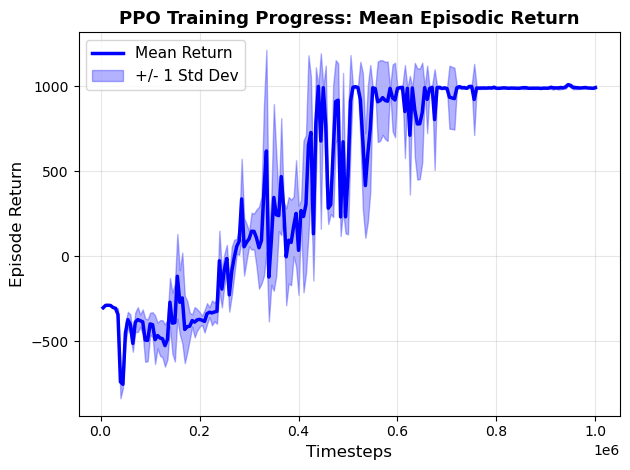


Training Statistics:
Initial mean return: -301.99
Final mean return: 992.01
Improvement: 1294.00


In [61]:
results_file_npz = os.path.join(dirname, 'evaluations.npz')

data = np.load(results_file_npz)
timesteps = data['timesteps']
results = data['results']

mean_returns = np.mean(results, axis=1)
std_returns = np.std(results, axis=1)

fig, ax = plt.subplots(1, 1)
ax.plot(timesteps, mean_returns, linewidth=2.5, label='Mean Return', color='blue')
ax.fill_between(
        timesteps,
        mean_returns - std_returns,
        mean_returns + std_returns,
        alpha=0.3,
        color='blue',
        label='+/- 1 Std Dev',
)
ax.set_xlabel('Timesteps', fontsize=12)
ax.set_ylabel('Episode Return', fontsize=12)
ax.set_title('PPO Training Progress: Mean Episodic Return', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

#best_idx = int(np.argmax(mean_returns))
print("\nTraining Statistics:")
print(f"Initial mean return: {mean_returns[0]:.2f}")
print(f"Final mean return: {mean_returns[-1]:.2f}")
#print(f"Best mean return: {mean_returns[best_idx]:.2f} at step {timesteps[best_idx]}")
print(f"Improvement: {mean_returns[-1] - mean_returns[0]:.2f}")


## Example Rollouts

Run the trained policy on several episodes and visualize the trajectories.


In [55]:
# Choose which model to load
# The best model
best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
trained_model = PPO.load(best_model_path, device='cpu')
print(f"Loaded best model: {best_model_path}")

# The final model after all training steps
#final_model_path = os.path.join(dirname, 'final_model.zip')
#trained_model = PPO.load(final_model_path, device='cpu')
#print(f"Loaded final model: {final_model_path}")

def rollout_trained_policy(model, env, episodes=20, seed=42):
    trajectories = []
    returns = []
    termination_counts = {}

    for episode in range(episodes):
        obs, _ = env.reset(seed=seed + episode)
        trajectory = {
            'obs': [obs.copy()],
            'positions': [obs[:2].copy()],
            'actions': [],
            'physical_actions': [],
            'rewards': [],
            'success': False,
            'termination_reason': None,
            'obstacle': env.obstacle_center.copy(),
        }

        total_reward = 0.0
        final_info = {}
        for step in range(env.max_num_steps):
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)

            trajectory['obs'].append(obs.copy())
            trajectory['positions'].append(obs[:2].copy())
            trajectory['actions'].append(action.copy())
            trajectory['physical_actions'].append(info['physical_action'].copy())
            trajectory['rewards'].append(reward)
            total_reward += reward
            final_info = info

            if terminated or truncated:
                break

        reason = final_info.get('termination_reason', 'unknown')
        trajectory['termination_reason'] = reason
        trajectory['success'] = bool(final_info.get('is_success', False))
        trajectory['total_reward'] = total_reward
        trajectory['positions'] = np.array(trajectory['positions'])
        trajectories.append(trajectory)
        returns.append(total_reward)
        termination_counts[reason] = termination_counts.get(reason, 0) + 1

        print(
            f"Episode {episode + 1:02d}: Return={total_reward:8.2f}, "
            f"Len={step + 1:3d}, Reason={reason}, "
            f"GoalDist={final_info.get('goal_distance', np.nan):.3f}, "
            f"Clearance={final_info.get('clearance', np.nan):.3f}"
        )

    successes = termination_counts.get('success', 0)
    print(f"\nSuccess rate: {successes}/{episodes} ({100 * successes / episodes:.1f}%)")
    return trajectories, returns

rollout_env = PlanarQuad()
trajectories, rollout_returns = rollout_trained_policy(trained_model, rollout_env, episodes=10, seed=42)


Loaded best model: planarquad_ppo\best_model\best_model.zip
Episode 01: Return= 1003.44, Len= 64, Reason=success, GoalDist=0.144, Clearance=0.869
Episode 02: Return= 1016.43, Len= 75, Reason=success, GoalDist=0.093, Clearance=0.726
Episode 03: Return= 1014.60, Len= 72, Reason=success, GoalDist=0.088, Clearance=1.715
Episode 04: Return= 1000.38, Len= 64, Reason=success, GoalDist=0.148, Clearance=0.728
Episode 05: Return= 1000.21, Len= 61, Reason=success, GoalDist=0.146, Clearance=1.071
Episode 06: Return= 1000.56, Len= 60, Reason=success, GoalDist=0.148, Clearance=1.808
Episode 07: Return=  987.26, Len= 53, Reason=success, GoalDist=0.149, Clearance=1.066
Episode 08: Return= 1002.18, Len= 66, Reason=success, GoalDist=0.147, Clearance=1.017
Episode 09: Return= 1012.43, Len= 71, Reason=success, GoalDist=0.093, Clearance=1.894
Episode 10: Return= 1002.68, Len= 64, Reason=success, GoalDist=0.149, Clearance=0.771

Success rate: 10/10 (100.0%)


Visualize trajectories of the rollouts

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


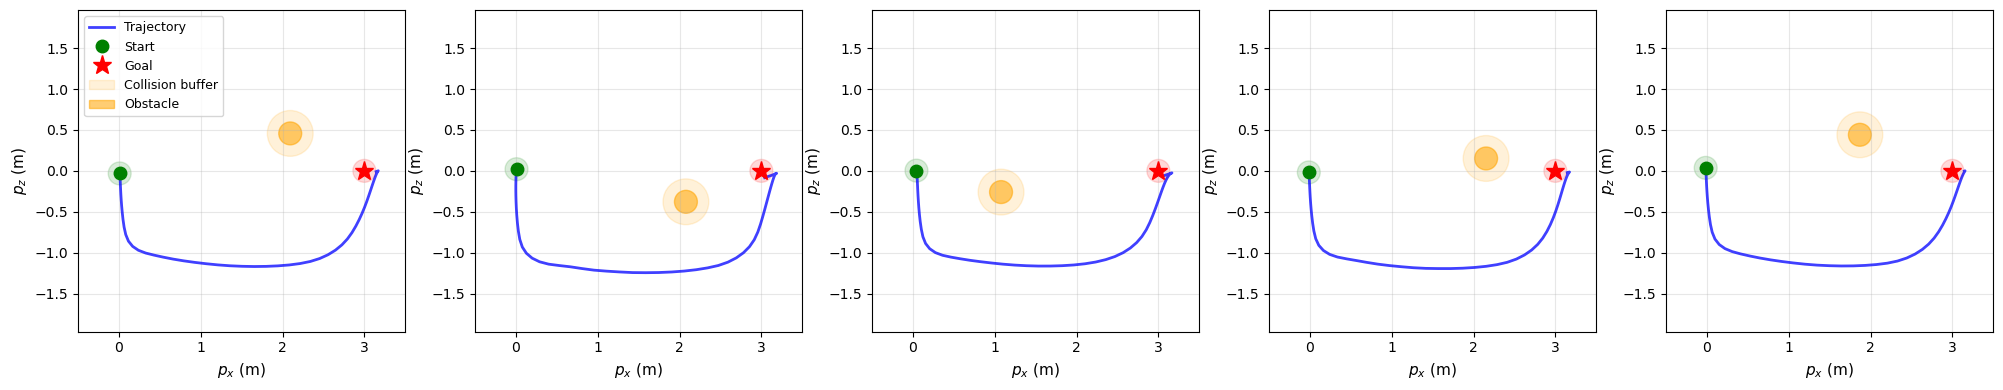


Rollout returns: [1003.44 1016.43 1014.6  1000.38 1000.21 1000.56  987.26 1002.18 1012.43
 1002.68]
Mean return: 1004.02
Std return: 8.14


In [56]:
num_plots = min(len(trajectories), 5)
fig, axes = plt.subplots(1, num_plots, figsize=(4 * num_plots, 4))
if num_plots == 1:
    axes = [axes]

for idx, traj in enumerate(trajectories[:num_plots]):
    ax = axes[idx]
    positions = traj['positions']

    ax.plot(positions[:, 0], positions[:, 1], 'b-', linewidth=2, label='Trajectory', alpha=0.75)
    ax.plot(positions[0, 0], positions[0, 1], 'go', markersize=9, label='Start', zorder=5)
    ax.plot(x_goal[0], x_goal[1], 'r*', markersize=14, label='Goal', zorder=5)

    obstacle_pos = traj['obstacle']
    obstacle = plt.Circle(obstacle_pos, r, color='orange', alpha=0.55, label='Obstacle')
    inflated = plt.Circle(obstacle_pos, 2 * r, color='orange', alpha=0.15, label='Collision buffer')
    ax.add_patch(inflated)
    ax.add_patch(obstacle)

    ax.add_patch(plt.Circle(positions[0], r, color='green', alpha=0.15))
    ax.add_patch(plt.Circle((x_goal[0], x_goal[1]), r, color='red', alpha=0.15))

    ax.set_xlabel('$p_x$ (m)', fontsize=11)
    ax.set_ylabel('$p_z$ (m)', fontsize=11)
    #title = f'Ep {idx + 1}: {traj["termination_reason"]}\nReturn={traj["total_reward"]:.1f}'
    #ax.set_title(title, fontsize=11, fontweight='bold', color='green' if traj['success'] else 'black')

    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if idx == 0:
        ax.legend(fontsize=9, loc='upper left')
    ax.set_xlim([-0.5, 3.5])
    ax.set_ylim([-1.5, 1.5])

plt.tight_layout()
plt.savefig(os.path.join(dirname, 'example_trajectories.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRollout returns: {np.round(rollout_returns, 2)}")
print(f"Mean return: {np.mean(rollout_returns):.2f}")
print(f"Std return: {np.std(rollout_returns):.2f}")


## Compare PPO with MPC

MPC Code from HW3 Part 1

In [ ]:
Q   = np.diag([10.0, 10.0, 5.0, 5.0, 5.0, 5.0]) * 0.1
Q_F = Q * 5.0
R   = np.diag([0.5, 0.5])

def unzip_decision_vars(z):
    n_state_vars = (N+1) * x_dim
    X = z[:n_state_vars].reshape(N+1, x_dim)
    U = z[n_state_vars:].reshape(N, u_dim)
    return X, U

def J(z):
    """Cost function"""
    X, U = unzip_decision_vars(z)
    #X_ref = reference_trajectory()

    total = 0.0
    for k in range(N):
        dx = X[k] - x_goal
        total += 0.5 * dx.T @ Q @ dx

    dxN = X[N] - x_goal
    total += 0.5 * dxN.T @ Q_F @ dxN

    for k in range(N):
        du = U[k] - u_ref
        total += 0.5 * du.T @ R @ du

    return total

def grad_J(z):
    """Gradient of the cost function w.r.t. z"""
    X, U = unzip_decision_vars(z)
    J_z = np.zeros_like(z)

    for k in range(N):
        idx = k * x_dim
        J_z[idx:idx + x_dim] = Q @ (X[k] - x_goal)

    idx = N * x_dim
    J_z[idx:idx + x_dim] = Q_F @ (X[N] - x_goal)

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        J_z[idx:idx + u_dim] = R @ (U[k] - u_ref)

    return J_z

def Hessian_J(z):
    """Hessian of the cost w.r.t. z"""
    H = np.zeros((z.size, z.size))

    for k in range(N):
        idx = k * x_dim
        H[idx:idx + x_dim, idx:idx + x_dim] = Q

    idx = N * x_dim
    H[idx:idx + x_dim, idx:idx + x_dim] = Q_F

    for k in range(N):
        idx = (N + 1) * x_dim + k * u_dim
        H[idx:idx + u_dim, idx:idx + u_dim] = R

    return H

# Equality constraints and Jacobian
def g(z, x_init):
    """Equality constraints"""
    X, U = unzip_decision_vars(z)
    g_val = []
    g_val.append(X[0] - x_init)
    for k in range(N):
        g_val.append(X[k + 1] - X[k] - dt * dynamics(X[k], U[k]))
    return np.concatenate(g_val) # or np.vstack?

def Jacobian_g(z):
    """Jacobian of the equality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    n_z = z.size
    J_g = np.zeros(((N+1) * x_dim, n_z))

    J_g[0:x_dim, 0:x_dim] = np.eye(x_dim)

    for k in range(N):
        x_k = X[k]
        u_k = U[k]

        A_k, B_k = Jacobian_dynamics(x_k, u_k)

        # derivative with respect to x_{k+1}
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((k+1)*x_dim):((k+2)*x_dim)] = np.eye(x_dim)

        # derivative with respect to x_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), (k*x_dim):((k+1)*x_dim)] = -(np.eye(x_dim) + dt * A_k)

        # derivative with respect to u_k
        J_g[((k+1)*x_dim):((k+2)*x_dim), ((N+1)*x_dim+k*u_dim):((N+1)*x_dim+(k+1)*u_dim)] = -(dt * B_k)

    return J_g

# Inequality constraints and Jacobian
def h(z, obstacle_center):
    """Inequality constraints"""
    X, U = unzip_decision_vars(z)
    h_val = []

    for k in range(N+1):
        d = X[k][:2] - obstacle_center
        h_val.append((2.0 * r) ** 2 - d @ d)

    return np.asarray(h_val, dtype=float)

def Jacobian_h(z, obstacle_center):
    """Jacobian of the inequality constraints w.r.t. z"""
    X, U = unzip_decision_vars(z)
    J_h = np.zeros((N+1, z.size))

    for k in range(N+1):
        grad = np.zeros(x_dim)
        grad[0] = -2.0 * (X[k][0] - obstacle_center[0])
        grad[1] = -2.0 * (X[k][1] - obstacle_center[1])
        J_h[k, (k*x_dim):((k+1)*x_dim)] = grad

    return J_h

def grad_L(z, lam, nu, obstacle_center):
    """Gradient of the Lagrangian function"""
    return grad_J(z) + Jacobian_g(z).T @ lam + Jacobian_h(z, obstacle_center).T @ nu

def Hessian_L(z, lam, nu, obstacle_center):
    """Hessian of the Lagrangian: approximated by the Hessian of the cost"""
    return Hessian_J(z)

def is_dominated(candidate_pair, pairs, verbose=False):
    """
    Returns True if candidate_pair is dominated by every pair in
    pairs, and False otherwise.
    """
    assert(len(candidate_pair) == 3)
    a_hat, b_hat, c_hat = candidate_pair
    for pair in pairs:
        a, b, c = pair
        if (a <= a_hat) and (b <= b_hat) and (c <= c_hat):
            if verbose:
                print(f'({a:6.3e}, {b:6.3e}, {c:6.3e}) dominates ({a_hat:6.3e}, {b_hat:6.3e}, {c_hat:6.3e})')
            return True
    return False

def solve_sqp(z, x_init, obstacle_center, verbose = True):

    lam = np.zeros((N+1)*x_dim)
    nu = np.zeros(N+1)

    res = [
        np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
        np.linalg.norm(g(z, x_init), np.inf),
        np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
    ]
    cost = J(z)

    # Create list of pairs for filter method
    pairs = [[J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)]]

    # Choose parameters
    max_iters = 500
    max_inner_iters = 10
    tol = 1e-5
    rho = 0.5
    delta = 1e-6
    omega = 10.0

    # Iterate
    alpha = None
    H = None
    mu = None
    success = False
    for i in range(max_iters):
        # Show progress
        mu_str = f' ; mu = {mu:.2e}' if mu is not None else ''
        alpha_str = f' ; alpha = {alpha:.2e}' if alpha is not None else ''
        if verbose:
            print(f'{i:3d} : |L_z| = {res[0]:11.8f}; |g| = {res[1]:11.8f}; |h| = {res[2]:11.8f}; J = {cost:7.4f}' + mu_str + alpha_str)

        # Check stopping condition (residuals)
        if (res[0] < tol) and (res[1] < tol) and (res[2] < tol):
            success = True
            if i == 0:
                print(f'success (initial guess satisfies necessary conditions for optimality)')
            else:
                print(f'success (converged at iteration {i})')
            break
        
        # Choose descent direction (Newton step with regularization)
        grad_J_val = grad_J(z)
        Hessian_L_val = Hessian_L(z, lam, nu, obstacle_center)
        #H = Hessian_L_val.copy()
        grad_L_val = grad_L(z, lam, nu, obstacle_center)
        Jacobian_g_val = Jacobian_g(z)
        g_val = g(z, x_init)
        Jacobian_h_val = Jacobian_h(z, obstacle_center)
        h_val = h(z, obstacle_center)
        mu_iters = 0
        while True:
            try:
                # Add regularization to the Hessian
                if mu_iters == 0:
                    mu = 0.0
                else:
                    mu = delta * (omega**mu_iters)
                H = Hessian_L_val + (mu * np.eye(len(z)))
                # Attempt a Cholesky factorization - if it fails, then H is not
                # positive definite and we need to add more regularization
                L_chol = np.linalg.cholesky(H)
                # Attempt to solve for the descent direction - if it fails, then
                # H is ill-conditioned and we need to add more regularization

                #problem = Problem(P=H, q=grad_L_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                # or
                problem = Problem(P=H, q=grad_J_val, A=Jacobian_g_val, b=-g_val, G=Jacobian_h_val, h=-h_val)
                solution = solve_problem(problem, solver='proxqp', eps_abs=1e-8, eps_rel=1e-8)
                step_z = solution.x
                #step_lam = solution.y
                #step_nu = solution.z
                step_lam = solution.y - lam
                step_nu = solution.z - nu
                #
                # ^^^ Be careful to distinguish between solution.y (dual variable
                #     associated with equality constraints) and solution.z (dual
                #     variable associated with inequality constraints). Get this
                #     wrong and you will have trouble finding your mistake!
                #
                break
            except np.linalg.LinAlgError:
                mu_iters += 1
        
        # Apply backtracking line search (filter method)
        alpha = 0.6
        no_progress = True
        for i_inner in range(max_inner_iters):
            if is_dominated([J(z + alpha * step_z),
                            np.linalg.norm(g(z + alpha * step_z, x_init), np.inf),
                            np.linalg.norm(np.maximum(0, h(z + alpha * step_z, obstacle_center)), np.inf)], 
                            pairs, verbose=False):
                alpha *= rho
            else:
                no_progress = False
                break
        
        # Check stopping condition (no progress)
        if no_progress:
            print(f'failure (no progress at iteration {i})')
            break

        # Update guess
        z = z + alpha * step_z
        lam = lam + alpha * step_lam
        nu = nu + alpha * step_nu

        res = [
            np.linalg.norm(grad_L(z, lam, nu, obstacle_center), np.inf),
            np.linalg.norm(g(z, x_init), np.inf),
            np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf),
        ]
        cost = J(z)
        pairs.append([J(z), np.linalg.norm(g(z, x_init), np.inf), np.linalg.norm(np.maximum(0, h(z, obstacle_center)), np.inf)])

    # Check if max iters was exceeded
    if (not success) and (i == max_iters-1):
        print(f'failure (exceeded maximum number {max_iters} of iterations)')

    return z

def run_mpc(obstacle_center, sim_time=sim_time):
    """MPC loop"""

    # Initialization: use hover at (0, 0) as the initial guess trajectory
    z = np.zeros((N+1)*x_dim + N*u_dim)
    z[:(N+1)*x_dim] = np.tile(x_start, N+1)
    z[(N+1)*x_dim:] = np.tile(u_ref, N)

    x = x_start.copy()

    x_hist = []
    u_hist = []

    tt = np.arange(0, sim_time, dt)

    for i in range(len(tt)):
        print("Time: ", tt[i])

        x_hist.append(x.copy())

        # Solve SQP
        z_opt = solve_sqp(z, x.copy(), obstacle_center, verbose=False)
        X_opt, U_opt = unzip_decision_vars(z_opt)

        # Apply the first control only
        u = U_opt[0].copy()
        u_hist.append(u)

        # Propagate the state with zero-order hold on control
        if i < len(tt) - 1:
            t_span = (tt[i], tt[i + 1])
            sol = solve_ivp(lambda t, y: dynamics(y, u),
                            t_span,
                            x,
                            t_eval = [tt[i + 1]],
                            rtol = 1e-9,
                            atol = 1e-9,
            )
            x = sol.y[:, -1]

        # Warm start the next SQP solver
        z = z_opt

    return np.asarray(x_hist), np.asarray(u_hist)

def plot_mpc_result(x_hist, u_hist, obstacle_center):

    tt = np.arange(u_hist.shape[0]) * dt

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].plot(x_hist[:, 0], x_hist[:, 1], label='drone trajectory')
    for i in range(x_hist.shape[0]):
        drone = plt.Circle([x_hist[i, 0], x_hist[i, 1]], r, color='blue', alpha=0.05)
        axes[0].add_patch(drone)
    axes[0].scatter([x_start[0], x_goal[0]], [x_start[1], x_goal[1]], c=['green', 'black'], label='start/goal')
    obstacle = plt.Circle(obstacle_center, r, color='red', alpha=0.3, label='obstacle')
    axes[0].add_patch(obstacle)
    axes[0].set_xlabel('$p_x$')
    axes[0].set_ylabel('$p_z$')
    axes[0].grid(True)
    axes[0].axis('equal')
    axes[0].legend()

    axes[1].plot(tt, u_hist[:, 0], label='$T_1$')
    axes[1].plot(tt, u_hist[:, 1], label='$T_2$')
    axes[1].set_xlabel('time (s)')
    axes[1].set_ylabel('Control Inputs')
    axes[1].grid(True)
    axes[1].legend()

    plt.show()

### PPO versus MPC on matched scenarios

The cells below compare the trained PPO policy and the MPC controller on the same initial state and obstacle locations. The PPO policy is evaluated using deterministic actions, while the MPC controller resolves the SQP problem at every control step. The timing comparison separates deployment decision time from simulation/integration time: PPO timing measures `model.predict`, and MPC timing measures `solve_sqp`.

Running scenario 1: obstacle=[1.2  0.45]
Running scenario 2: obstacle=[1.55 0.  ]
Running scenario 3: obstacle=[ 2.   -0.45]


,scenario,obstacle_x,obstacle_z,ppo_success,ppo_reason,ppo_steps,ppo_return,ppo_goal_dist,ppo_min_clearance,ppo_path_length,ppo_decision_ms,mpc_success,mpc_reason,mpc_steps,mpc_goal_dist,mpc_min_clearance,mpc_path_length,mpc_decision_ms,mpc_min_thrust,mpc_max_thrust
0,1,1.20,0.45,True,success,61,999.4673,0.1469,1.0016,4.6188,0.2966,False,horizon_end,125,0.1605,0.0700,2.8624,101.2984,0.8526,3.3573
1,2,1.55,0.00,True,success,73,1016.7953,0.0727,0.9070,4.7814,0.2361,False,horizon_end,125,0.1678,0.0027,3.1300,103.7994,0.8526,3.3573
2,3,2.00,-0.45,True,success,74,1015.1063,0.0949,0.4937,4.9870,0.2324,False,horizon_end,125,0.1605,0.2109,2.8624,98.7512,0.8526,3.3573


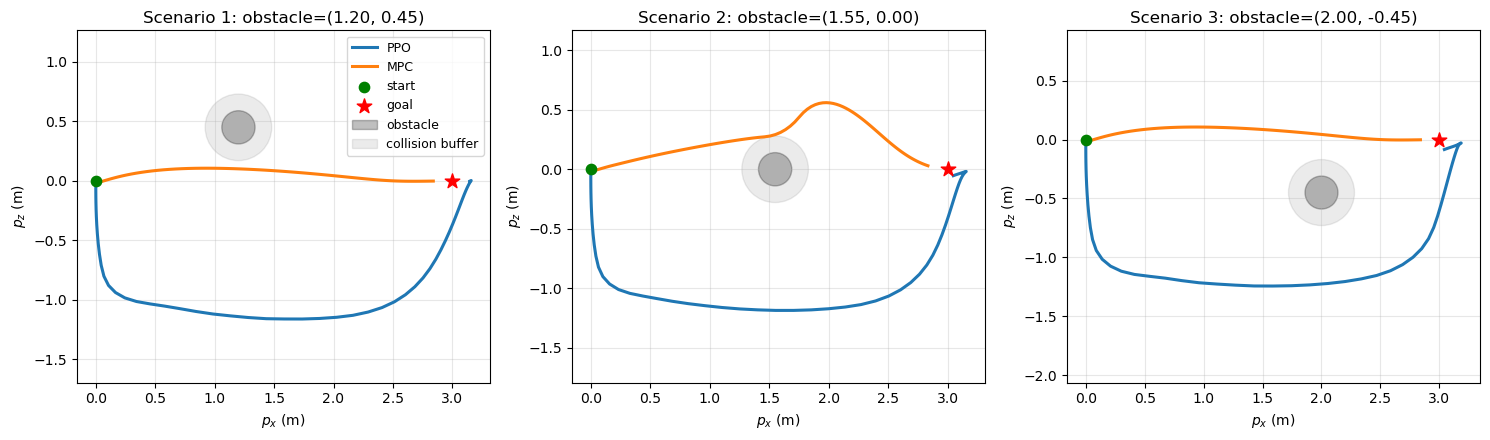

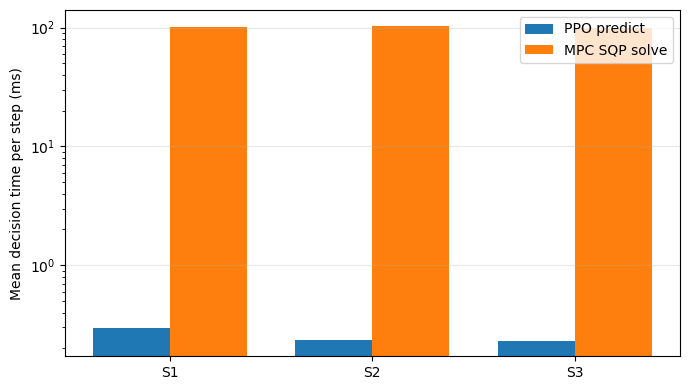


Discussion:
- PPO reached the goal in 3/3 scenarios; MPC reached the goal in 0/3 completed MPC scenarios over a 5.0 s horizon.
- Mean deployment decision time was 0.2550 ms for PPO inference versus 101.2830 ms for the MPC SQP solve, about 397.2x slower for MPC.
- Mean path length was 4.796 m for PPO and 2.952 m for MPC.
- In the trajectory plots, PPO is a trained reactive policy: once trained, it only runs a neural-network forward pass at deployment, so it is much faster but only approximately respects obstacle clearance through the learned reward.
- MPC replans from the current state by solving a constrained optimization problem at each step. It is typically more deliberate around the obstacle and gives an explicit planned trajectory, but the online optimization dominates deployment computation time.


In [62]:
import contextlib
import io
import time

from stable_baselines3 import PPO

if 'trained_model' not in globals():
    best_model_path = os.path.join(dirname, 'best_model', 'best_model.zip')
    trained_model = PPO.load(best_model_path, device='cpu')
    print(f'Loaded best model: {best_model_path}')

comparison_obstacles = np.array([
    [1.20,  0.45],
    [1.55,  0.00],
    [2.00, -0.45],
], dtype=np.float64)

comparison_sim_time = sim_time
comparison_x0 = x_start.copy()

def classify_terminal_state(state, obstacle_center):
    goal_distance = float(np.linalg.norm(x_goal[:2] - state[:2]))
    speed = float(np.linalg.norm(state[3:5]))
    angle = abs(float(((state[2] + np.pi) % (2 * np.pi)) - np.pi))
    omega = abs(float(state[5]))
    obstacle_distance = float(np.linalg.norm(state[:2] - obstacle_center))
    clearance = obstacle_distance - 2.0 * r
    out_of_bounds = bool(np.any(state < DEFAULT_STATE_LIMIT[:, 0]) or np.any(state > DEFAULT_STATE_LIMIT[:, 1]))
    collision = bool(clearance <= 0.0)
    success = bool(
        goal_distance <= PlanarQuad().goal_position_tolerance
        and speed <= PlanarQuad().goal_velocity_tolerance
        and angle <= PlanarQuad().goal_angle_tolerance
        and omega <= PlanarQuad().goal_omega_tolerance
    )
    if success:
        reason = 'success'
    elif collision:
        reason = 'collision'
    elif out_of_bounds:
        reason = 'out_of_bounds'
    else:
        reason = 'horizon_end'
    return success, reason, goal_distance, clearance

def path_length(positions):
    if len(positions) < 2:
        return 0.0
    return float(np.sum(np.linalg.norm(np.diff(positions, axis=0), axis=1)))

def rollout_ppo_scenario(model, obstacle_center, x0=comparison_x0):
    env = PlanarQuad(random_start=False, random_obstacle=False, obstacle=obstacle_center, start_noise=np.zeros(x_dim))
    obs, _ = env.reset(options={'x0': x0, 'obstacle': obstacle_center, 'random_start': False, 'random_obstacle': False})

    states = [env.state.copy()]
    normalized_actions = []
    physical_actions = []
    rewards = []
    predict_times = []
    final_info = {}

    rollout_start = time.perf_counter()
    for _ in range(env.max_num_steps):
        decision_start = time.perf_counter()
        action, _ = model.predict(obs, deterministic=True)
        predict_times.append(time.perf_counter() - decision_start)

        obs, reward, terminated, truncated, info = env.step(action)
        states.append(env.state.copy())
        normalized_actions.append(np.array(action, dtype=np.float64).copy())
        physical_actions.append(info['physical_action'].copy())
        rewards.append(float(reward))
        final_info = info
        if terminated or truncated:
            break
    rollout_time = time.perf_counter() - rollout_start

    states = np.asarray(states)
    physical_actions = np.asarray(physical_actions)
    success, reason, goal_distance, final_clearance = classify_terminal_state(states[-1], obstacle_center)
    reason = final_info.get('termination_reason') or reason
    success = bool(final_info.get('is_success', success))
    clearances = np.linalg.norm(states[:, :2] - obstacle_center, axis=1) - 2.0 * r

    return {
        'states': states,
        'positions': states[:, :2],
        'actions': np.asarray(normalized_actions),
        'physical_actions': physical_actions,
        'return': float(np.sum(rewards)),
        'steps': len(rewards),
        'success': success,
        'reason': reason,
        'goal_distance': goal_distance,
        'final_clearance': final_clearance,
        'min_clearance': float(np.min(clearances)),
        'path_length': path_length(states[:, :2]),
        'decision_times': np.asarray(predict_times),
        'decision_time_total': float(np.sum(predict_times)),
        'decision_time_mean': float(np.mean(predict_times)) if predict_times else np.nan,
        'rollout_time': rollout_time,
    }

def run_mpc_timed_scenario(obstacle_center, sim_time=comparison_sim_time, x0=comparison_x0, suppress_solver_output=True):
    z = np.zeros((N + 1) * x_dim + N * u_dim)
    z[:(N + 1) * x_dim] = np.tile(x0, N + 1)
    z[(N + 1) * x_dim:] = np.tile(u_ref, N)

    x = x0.copy()
    x_hist = []
    u_hist = []
    solve_times = []
    tt = np.arange(0.0, sim_time, dt)

    rollout_start = time.perf_counter()
    for i, t in enumerate(tt):
        x_hist.append(x.copy())

        solve_start = time.perf_counter()
        if suppress_solver_output:
            with contextlib.redirect_stdout(io.StringIO()):
                z_opt = solve_sqp(z, x.copy(), obstacle_center, verbose=False)
        else:
            z_opt = solve_sqp(z, x.copy(), obstacle_center, verbose=False)
        solve_times.append(time.perf_counter() - solve_start)
        X_opt, U_opt = unzip_decision_vars(z_opt)

        u = U_opt[0].copy()
        u_hist.append(u)

        if i < len(tt) - 1:
            sol = solve_ivp(
                lambda tau, y: dynamics(y, u),
                (tt[i], tt[i + 1]),
                x,
                t_eval=[tt[i + 1]],
                rtol=1e-9,
                atol=1e-9,
            )
            if not sol.success:
                raise RuntimeError(sol.message)
            x = sol.y[:, -1]
            x[2] = ((x[2] + np.pi) % (2 * np.pi)) - np.pi

        z = z_opt
    rollout_time = time.perf_counter() - rollout_start

    states = np.asarray(x_hist)
    controls = np.asarray(u_hist)
    success, reason, goal_distance, final_clearance = classify_terminal_state(states[-1], obstacle_center)
    clearances = np.linalg.norm(states[:, :2] - obstacle_center, axis=1) - 2.0 * r

    return {
        'states': states,
        'positions': states[:, :2],
        'physical_actions': controls,
        'steps': len(controls),
        'success': success,
        'reason': reason,
        'goal_distance': goal_distance,
        'final_clearance': final_clearance,
        'min_clearance': float(np.min(clearances)),
        'path_length': path_length(states[:, :2]),
        'decision_times': np.asarray(solve_times),
        'decision_time_total': float(np.sum(solve_times)),
        'decision_time_mean': float(np.mean(solve_times)) if solve_times else np.nan,
        'rollout_time': rollout_time,
    }

comparison_records = []
comparison_rows = []

for scenario_id, obstacle_center in enumerate(comparison_obstacles, start=1):
    print(f'Running scenario {scenario_id}: obstacle={obstacle_center}')
    ppo_result = rollout_ppo_scenario(trained_model, obstacle_center)
    try:
        mpc_result = run_mpc_timed_scenario(obstacle_center)
        mpc_error = None
    except Exception as err:
        mpc_result = None
        mpc_error = repr(err)
        print(f'  MPC failed: {mpc_error}')

    comparison_records.append({
        'scenario': scenario_id,
        'obstacle': obstacle_center,
        'ppo': ppo_result,
        'mpc': mpc_result,
        'mpc_error': mpc_error,
    })

    row = {
        'scenario': scenario_id,
        'obstacle_x': obstacle_center[0],
        'obstacle_z': obstacle_center[1],
        'ppo_success': ppo_result['success'],
        'ppo_reason': ppo_result['reason'],
        'ppo_steps': ppo_result['steps'],
        'ppo_return': ppo_result['return'],
        'ppo_goal_dist': ppo_result['goal_distance'],
        'ppo_min_clearance': ppo_result['min_clearance'],
        'ppo_path_length': ppo_result['path_length'],
        'ppo_decision_ms': 1e3 * ppo_result['decision_time_mean'],
    }
    if mpc_result is not None:
        row.update({
            'mpc_success': mpc_result['success'],
            'mpc_reason': mpc_result['reason'],
            'mpc_steps': mpc_result['steps'],
            'mpc_goal_dist': mpc_result['goal_distance'],
            'mpc_min_clearance': mpc_result['min_clearance'],
            'mpc_path_length': mpc_result['path_length'],
            'mpc_decision_ms': 1e3 * mpc_result['decision_time_mean'],
            'mpc_min_thrust': float(np.min(mpc_result['physical_actions'])),
            'mpc_max_thrust': float(np.max(mpc_result['physical_actions'])),
        })
    else:
        row.update({
            'mpc_success': False,
            'mpc_reason': mpc_error,
            'mpc_steps': 0,
            'mpc_goal_dist': np.nan,
            'mpc_min_clearance': np.nan,
            'mpc_path_length': np.nan,
            'mpc_decision_ms': np.nan,
            'mpc_min_thrust': np.nan,
            'mpc_max_thrust': np.nan,
        })
    comparison_rows.append(row)

try:
    import pandas as pd
    comparison_df = pd.DataFrame(comparison_rows)
    display(comparison_df.round(4))
except ImportError:
    comparison_df = comparison_rows
    for row in comparison_rows:
        print(row)

fig, axes = plt.subplots(1, len(comparison_records), figsize=(5 * len(comparison_records), 4.5), squeeze=False)
for ax, record in zip(axes[0], comparison_records):
    obstacle_center = record['obstacle']
    ppo = record['ppo']
    mpc = record['mpc']

    ax.plot(ppo['positions'][:, 0], ppo['positions'][:, 1], color='tab:blue', linewidth=2.2, label='PPO')
    if mpc is not None:
        ax.plot(mpc['positions'][:, 0], mpc['positions'][:, 1], color='tab:orange', linewidth=2.2, label='MPC')

    ax.scatter([comparison_x0[0]], [comparison_x0[1]], c='green', s=55, label='start', zorder=5)
    ax.scatter([x_goal[0]], [x_goal[1]], c='red', marker='*', s=120, label='goal', zorder=5)
    ax.add_patch(plt.Circle(obstacle_center, r, color='black', alpha=0.25, label='obstacle'))
    ax.add_patch(plt.Circle(obstacle_center, 2 * r, color='black', alpha=0.08, label='collision buffer'))
    ax.set_title(f'Scenario {record["scenario"]}: obstacle=({obstacle_center[0]:.2f}, {obstacle_center[1]:.2f})')
    ax.set_xlabel('$p_x$ (m)')
    ax.set_ylabel('$p_z$ (m)')
    ax.set_xlim([-0.5, 3.5])
    ax.set_ylim([-1.5, 1.5])
    ax.grid(True, alpha=0.3)
    ax.axis('equal')
    if record['scenario'] == 1:
        ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.savefig(os.path.join(dirname, 'ppo_vs_mpc_matched_scenarios.png'), dpi=150, bbox_inches='tight')
plt.show()

valid_rows = [row for row in comparison_rows if np.isfinite(row['mpc_decision_ms'])]
if valid_rows:
    labels = [f'S{row["scenario"]}' for row in valid_rows]
    x = np.arange(len(valid_rows))
    width = 0.38
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(x - width / 2, [row['ppo_decision_ms'] for row in valid_rows], width, label='PPO predict')
    ax.bar(x + width / 2, [row['mpc_decision_ms'] for row in valid_rows], width, label='MPC SQP solve')
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel('Mean decision time per step (ms)')
    ax.set_yscale('log')
    ax.grid(True, axis='y', alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(dirname, 'ppo_vs_mpc_decision_time.png'), dpi=150, bbox_inches='tight')
    plt.show()

def print_comparison_discussion(rows):
    valid = [row for row in rows if np.isfinite(row['mpc_decision_ms'])]
    ppo_successes = sum(bool(row['ppo_success']) for row in rows)
    mpc_successes = sum(bool(row['mpc_success']) for row in valid)

    print('\nDiscussion:')
    print(f'- PPO reached the goal in {ppo_successes}/{len(rows)} scenarios; MPC reached the goal in {mpc_successes}/{len(valid)} completed MPC scenarios over a {comparison_sim_time:.1f} s horizon.')
    if valid:
        mean_ppo_ms = float(np.mean([row['ppo_decision_ms'] for row in valid]))
        mean_mpc_ms = float(np.mean([row['mpc_decision_ms'] for row in valid]))
        speed_ratio = mean_mpc_ms / mean_ppo_ms if mean_ppo_ms > 0 else np.inf
        print(f'- Mean deployment decision time was {mean_ppo_ms:.4f} ms for PPO inference versus {mean_mpc_ms:.4f} ms for the MPC SQP solve, about {speed_ratio:.1f}x slower for MPC.')
        print(f'- Mean path length was {np.mean([row["ppo_path_length"] for row in valid]):.3f} m for PPO and {np.mean([row["mpc_path_length"] for row in valid]):.3f} m for MPC.')
        if any((row['mpc_min_thrust'] < 0.0) or (row['mpc_max_thrust'] > 10.0) for row in valid):
            print('- The MPC formulation used here does not impose the same [0, 10] N thrust bounds as the PPO environment, so any MPC thrust outside that range should be treated as an implementation/modeling caveat.')
    print('- In the trajectory plots, PPO is a trained reactive policy: once trained, it only runs a neural-network forward pass at deployment, so it is much faster but only approximately respects obstacle clearance through the learned reward.')
    print('- MPC replans from the current state by solving a constrained optimization problem at each step. It is typically more deliberate around the obstacle and gives an explicit planned trajectory, but the online optimization dominates deployment computation time.')

print_comparison_discussion(comparison_rows)


The important deployment distinction is that PPO moves almost all of its computational cost offline into training. At runtime it only evaluates the learned policy network. MPC has no training phase here, but it pays for a new constrained optimization problem at every control step. This is why the trajectory comparison and the timing bar chart should be read together: MPC may produce more optimization-shaped obstacle avoidance, while PPO is usually much cheaper online and may be less conservative depending on what it learned from the reward.